In [ ]:
!pip install --no-cache-dir transformers[torch] datasets evaluate accelerate scikit-learn bitsandbytes

import os
import torch
import numpy as np
import pandas as pd
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

try:
    import evaluate
    HAS_EVALUATE = True
except ImportError:
    HAS_EVALUATE = False
    print("Aviso: 'evaluate' não disponível. Usaremos fallback para metrics.")

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Utilizando o dispositivo: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 188.8 MB/s eta 0:00:00
Utilizando o dispositivo: cuda


### 1. Carregamento e Preparação dos Dados


In [ ]:
import pandas as pd

paths = [
    "/content/drive/MyDrive/MINA-BR-Rotulada.csv",
    "/content/drive/MyDrive/dataset_misoginia_finalizado.csv",
    "/content/drive/MyDrive/dados_artificiais.csv"
]

def load_and_preprocess(path):
    try:
        df = pd.read_csv(path)
    except:
        df = pd.read_csv(path, sep=';')

    print(f"Arquivo: {path.split('/')[-1]} | Colunas: {df.columns.tolist()}")
    return df

dfs = [load_and_preprocess(p) for p in paths]

display(dfs[0].head())

Arquivo: MINA-BR-Rotulada.csv | Colunas: ['certeza_disc_clas_1', 'certeza_disc_clas_2', 'certeza_disc_clas_3', 'certeza_ofens_clas_1', 'certeza_ofens_clas_2', 'certeza_ofens_clas_3', 'comment', 'date', 'disc_clas_1', 'disc_clas_2', 'disc_clas_3', 'id_autor_1', 'id_autor_2', 'id_autor_3', 'keyword', 'ofens_clas_1', 'ofens_clas_2', 'ofens_clas_3', 'source', 'odio']
Arquivo: dataset_misoginia_finalizado.csv | Colunas: ['certeza_disc_clas_1', 'certeza_disc_clas_2', 'certeza_disc_clas_3', 'certeza_ofens_clas_1', 'certeza_ofens_clas_2', 'certeza_ofens_clas_3', 'comment', 'date', 'disc_clas_1', 'disc_clas_2', 'disc_clas_3', 'id_autor_1', 'id_autor_2', 'id_autor_3', 'keyword', 'ofens_clas_1', 'ofens_clas_2', 'ofens_clas_3', 'source', 'odio', 'label_assedio', 'label_ameaca', 'label_descredito', 'label_misoginia_geral']
Arquivo: dados_artificiais.csv | Colunas: ['id', 'texto', 'rotulo']


,certeza_disc_clas_1,certeza_disc_clas_2,certeza_disc_clas_3,certeza_ofens_clas_1,certeza_ofens_clas_2,certeza_ofens_clas_3,comment,date,disc_clas_1,disc_clas_2,disc_clas_3,id_autor_1,id_autor_2,id_autor_3,keyword,ofens_clas_1,ofens_clas_2,ofens_clas_3,source,odio
0,-1.0,-1.0,4.0,4.0,5.0,4.0,Eu fui ver o Twitter da garota e já dou de car...,2020-12-23 21:17:31,0.0,0.0,1.0,-MbqEhLQ5DHE4JKVnSYz,-MbrOtpTLDyCIXXqMS8s,-MbxUAktPHOvanZLgccl,antifeminista,0.0,0.0,1.0,Twitter,0
1,5.0,1.0,5.0,5.0,5.0,5.0,@NOME @NOME Jaja te bloqueio denovo seu resto ...,2020-12-27 20:51:47,0.0,0.0,1.0,-MbrXeGPm84uPDqKwzsp,-MbxCpLCV0T1V7o0TS8U,-Mc-A6HAii__JnTbfS87,mal_comida,1.0,1.0,1.0,Twitter,0
2,-1.0,-1.0,-1.0,5.0,5.0,5.0,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,2020-12-24 14:16:29,0.0,0.0,0.0,-MbpxGPiip0WCKKay75Y,-MbxAkmihTQeEppUb3js,-MbxCzO_1ftJ-VJJcgJv,antifeminista,0.0,0.0,0.0,Twitter,0
3,-1.0,-1.0,-1.0,4.0,5.0,5.0,Quando vejo uma mulher antifeminista eu só con...,2020-12-23 19:31:28,0.0,0.0,0.0,-MbneJBhF1GNC7xPlc-V,-MbqFQINR5epWplcJrfU,-Mbwgys1T2GNBckrws-l,antifeminista,0.0,0.0,0.0,Twitter,0
4,5.0,5.0,4.0,5.0,5.0,3.0,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,2020-12-20 18:04:36,1.0,1.0,1.0,-MbqHpEUMADtFHR3ci3y,-MbvHmh93AGhmpw2J54j,-MbxDaKZSOQDgemnY-H6,feminazi,1.0,1.0,1.0,Twitter,1


### 2. Unificação e Mapeamento de Categorias


In [ ]:
for i in range(len(dfs)):
    rename_dict = {
        'comment': 'text',
        'texto': 'text',
        'rotulo': 'label',
        'odio': 'label'
    }
    dfs[i] = dfs[i].rename(columns=rename_dict)

df_final = pd.concat([df[['text', 'label']] for df in dfs if 'text' in df.columns and 'label' in df.columns], ignore_index=True)

df_final = df_final.dropna(subset=['text', 'label'])
df_final = df_final.drop_duplicates(subset=['text'])

print(f"Total de exemplos após unificação: {len(df_final)}")
print("Distribuição inicial das classes:")
print(df_final['label'].value_counts())

display(df_final.head())

Total de exemplos após unificação: 3801
Distribuição inicial das classes:
label
0                         1738
Misoginia Geral            448
Assédio Sexual             443
Descrédito Intelectual     363
1                          338
Ameaça Física              255
Não-Misógino               215
rotulo                       1
Name: count, dtype: int64


,text,label
0,Eu fui ver o Twitter da garota e já dou de car...,0
1,@NOME @NOME Jaja te bloqueio denovo seu resto ...,0
2,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,0
3,Quando vejo uma mulher antifeminista eu só con...,0
4,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,1


### 3. Mapeamento para Categorias Alvo


In [ ]:
target_categories = [
    "Descrédito Intelectual",
    "Assédio Sexual",
    "Misoginia Geral",
    "Ameaça Física",
    "Não-Misógino"
]

mapping = {
    0: "Não-Misógino",
    1: "Misoginia Geral",
    "0": "Não-Misógino",
    "1": "Misoginia Geral",
    "Não-Misógino": "Não-Misógino",
    "Misoginia Geral": "Misoginia Geral",
    "Assédio Sexual": "Assédio Sexual",
    "Descrédito Intelectual": "Descrédito Intelectual",
    "Ameaça Física": "Ameaça Física"
}

df_final['label'] = df_final['label'].map(lambda x: mapping.get(x, x))

df_final = df_final[df_final['label'].isin(target_categories)].copy()

labels = sorted(df_final['label'].unique())
id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

df_final['label_id'] = df_final['label'].map(label2id)

print("Distribuição Final por Categoria:")
print(df_final['label'].value_counts())
display(df_final.head())

Distribuição Final por Categoria:
label
Não-Misógino              1953
Misoginia Geral            786
Assédio Sexual             443
Descrédito Intelectual     363
Ameaça Física              255
Name: count, dtype: int64


,text,label,label_id
0,Eu fui ver o Twitter da garota e já dou de car...,Não-Misógino,4
1,@NOME @NOME Jaja te bloqueio denovo seu resto ...,Não-Misógino,4
2,@NOME @NOME @NOME @NOME O link n ta abrindo p ...,Não-Misógino,4
3,Quando vejo uma mulher antifeminista eu só con...,Não-Misógino,4
4,@NOME Mulher bonita e sem frescuras 😍😍😍....o t...,Misoginia Geral,3


### 4. Tokenização e Divisão dos Dados
Tokenizador do BERTomelo e preparar o dataset para o treinamento.

In [ ]:
from transformers import AutoTokenizer
from datasets import Dataset

model_checkpoint = "unb-labia/BERTomelo-ModernBERT-Large-v1"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=64)

try:
    dataset = Dataset.from_pandas(df_final[['text', 'label_id']].rename(columns={'label_id': 'label'}))
    train_testvalid = dataset.train_test_split(test_size=0.2, seed=42)
    tokenized_datasets = train_testvalid.map(tokenize_function, batched=True)
    print(f"Tokenização concluída com max_length=64 usando: {model_checkpoint}")
except NameError:
    print("Erro: 'df_final' não encontrado.")

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/971 [00:00<?, ?B/s]

Map:   0%|          | 0/3040 [00:00<?, ? examples/s]

Map:   0%|          | 0/760 [00:00<?, ? examples/s]

Tokenização concluída com max_length=64 usando: unb-labia/BERTomelo-ModernBERT-Large-v1


### 5. Melhores Práticas para Dados Desbalanceados
Calculando pesos para equilibrar a importância das classes minoritárias durante o treinamento.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import torch
from torch import nn

y_train = tokenized_datasets['train']['label']
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float).to(device)

print("Pesos calculados por classe:")
for i, w in enumerate(weights):
    print(f"{id2label[i]}: {w:.2f}")

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

Pesos calculados por classe:
Ameaça Física: 3.20
Assédio Sexual: 1.70
Descrédito Intelectual: 2.03
Misoginia Geral: 0.95
Não-Misógino: 0.39


### 6. Treinamento Otimizado com Pesos


In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import torch
from torch import nn
import numpy as np
import evaluate
import gc

target_categories = ["Ameaça Física", "Assédio Sexual", "Descrédito Intelectual", "Misoginia Geral", "Não-Misógino"]
id2label = {i: label for i, label in enumerate(target_categories)}
label2id = {label: i for i, label in enumerate(target_categories)}
class_weights = torch.tensor([3.20, 1.70, 2.03, 0.95, 0.39], dtype=torch.float).to("cuda")

gc.collect()
torch.cuda.empty_cache()

metric = evaluate.load("f1")
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

class FinalRobustTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.15)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

model_opt = AutoModelForSequenceClassification.from_pretrained(
    "unb-labia/BERTomelo-ModernBERT-Large-v1",
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
    classifier_dropout=0.3
)

model_opt.gradient_checkpointing_enable()

training_args_final = TrainingArguments(
    output_dir="./results_optimized",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=5e-6,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    num_train_epochs=3,
    weight_decay=0.3,
    warmup_steps=200,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=True,
    logging_steps=10,
    report_to="none"
)

optimized_trainer = FinalRobustTrainer(
    model=model_opt,
    args=training_args_final,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("Iniciando treinamento otimizado contra Overfitting...")
optimized_trainer.train()

model.safetensors:   0%|          | 0.00/1.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: unb-labia/BERTomelo-ModernBERT-Large-v1
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Iniciando treinamento otimizado contra Overfitting...


Epoch,Training Loss,Validation Loss,F1
1,11.266024,1.105185,0.789149
2,9.669436,1.015876,0.875171
3,9.690833,0.998994,0.886102


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=570, training_loss=11.521816762288411, metrics={'train_runtime': 1055.7993, 'train_samples_per_second': 8.638, 'train_steps_per_second': 0.54, 'total_flos': 1205624621445120.0, 'train_loss': 11.521816762288411, 'epoch': 3.0})

### 7. Configuração do Modelo e Treinamento
Carregamos o modelo base **BERTomelo-ModernBERT-Large-v1** para classificação. Configuramos o `Macro F1-Score` como métrica principal para garantir que o modelo aprenda a identificar as categorias de misoginia de forma equilibrada.

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate

metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels, average="macro")

model = AutoModelForSequenceClassification.from_pretrained(
    "unb-labia/BERTomelo-ModernBERT-Large-v1",
    num_labels=len(target_categories),
    id2label=id2label,
    label2id=label2id
)

training_args = TrainingArguments(
    output_dir="./results_bertomelo_base",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_steps=10,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

print("Modelo BERTomelo-ModernBERT-Large-v1 configurado e pronto para o treinamento básico.")

Loading weights:   0%|          | 0/172 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: unb-labia/BERTomelo-ModernBERT-Large-v1
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.weight | MISSING    | 
classifier.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Modelo BERTomelo-ModernBERT-Large-v1 configurado e pronto para o treinamento básico.


### 8. Execução do Fine-tuning


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1
1,0.330086,0.323851,0.886215
2,0.082478,0.481503,0.895542
3,0.004101,0.687997,0.907255


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=570, training_loss=0.1918679112129898, metrics={'train_runtime': 684.5527, 'train_samples_per_second': 13.323, 'train_steps_per_second': 0.833, 'total_flos': 1205624621445120.0, 'train_loss': 0.1918679112129898, 'epoch': 3.0})

### 9. Avaliação Qualitativa e Quantitativa
Métricas finais no conjunto de teste e visualizar o desempenho por categoria através de uma matriz de confusão.

                        precision    recall  f1-score   support

         Ameaça Física       0.83      0.97      0.89        65
        Assédio Sexual       0.94      0.94      0.94        86
Descrédito Intelectual       0.91      0.95      0.93        64
       Misoginia Geral       0.76      0.78      0.77       143
          Não-Misógino       0.92      0.88      0.90       402

              accuracy                           0.88       760
             macro avg       0.87      0.90      0.89       760
          weighted avg       0.88      0.88      0.88       760



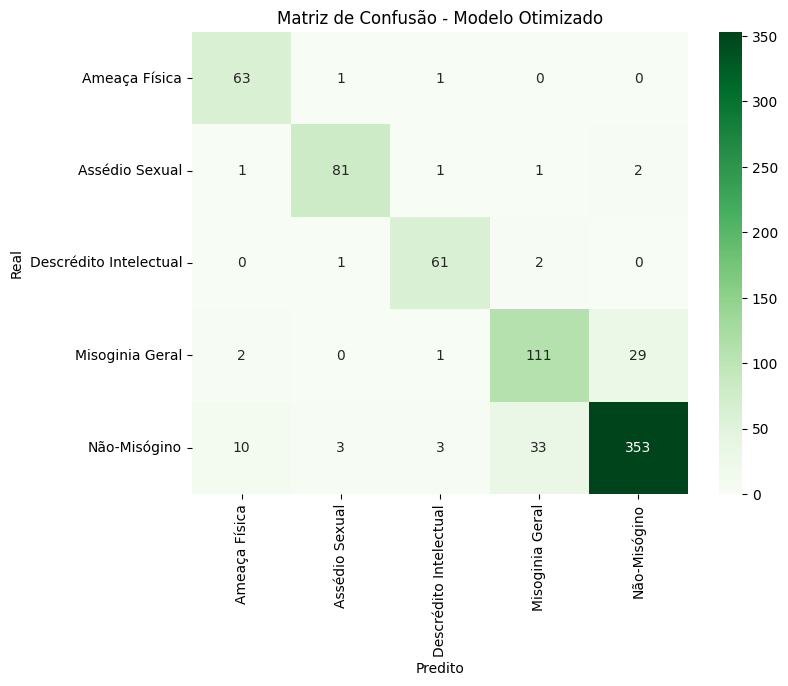

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch

predictions = optimized_trainer.predict(tokenized_datasets["test"])
y_probs = torch.nn.functional.softmax(torch.from_numpy(predictions.predictions), dim=-1).numpy()
y_pred = np.argmax(y_probs, axis=-1)
y_true = predictions.label_ids

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Greens')
plt.title('Matriz de Confusão - Modelo Otimizado')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

### 10. Teste Prático (Inferência)


In [ ]:
import re
import torch

def clean_text(text):
    text = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', text)
    return text.strip()

def predict_misogyny_optimized(text):
    cleaned_text = clean_text(text)
    inputs = tokenizer(cleaned_text, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    model_opt.eval()
    with torch.no_grad():
        outputs = model_opt(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
    pred_idx = torch.argmax(probs).item()

    return {
        "categoria": id2label[pred_idx],
        "confianca": f"{probs[0][pred_idx].item():.2%}"
    }

testes = [
    "Lugar de mulher é na cozinha, ela não entende nada de política.",
    "Você é muito burra para discutir esse assunto de economia.",
    "Vou te pegar na saída da faculdade e você vai ver o que te espera."
]

print("--- Teste de Inferência ---")
for t in testes:
    res = predict_misogyny_optimized(t)
    print(f"Texto: {t}\nResultado: {res['categoria']} ({res['confianca']})\n")

--- Teste de Inferência ---
Texto: Lugar de mulher é na cozinha, ela não entende nada de política.
Resultado: Descrédito Intelectual (44.51%)

Texto: Você é muito burra para discutir esse assunto de economia.
Resultado: Descrédito Intelectual (56.86%)

Texto: Vou te pegar na saída da faculdade e você vai ver o que te espera.
Resultado: Ameaça Física (95.75%)

